---
title: Advanced Statistical Data Analysis
authors:
  - name: Anna Drewek
    affiliation: ZHAW School of Engineering
  - name: Andreas Ruckstuhl
    affiliation: ZHAW School of Engineering
exports:
- format: pdf
  template: plain_latex_book
  output: Advanced-Statistical-Data-Analysis.pdf
  id: advanced-statistical-data-analysis-pdf
downloads:
  - id: advanced-statistical-data-analysis-pdf
    title: Download as PDF
---

In [27]:
# Install and load required packages
install.packages("boot")
install.packages("car")
install.packages("MASS")
install.packages("mgcv")
install.packages("splines")
install.packages("gRbase")
install.packages("gRain")
install.packages("pcalg")
install.packages("AER")

library(DAAG)
library(boot)
library(car)
library(MASS)
library(mgcv)
library(splines)
library(gRbase)
library(gRain)
library(pcalg)
library(AER)

# Load custom datasets from advanced-statistical-data-analysis/ folder
# Challenger O-ring data
chal <- read.table("advanced-statistical-data-analysis/O-rings.dat", header = TRUE)

# Dial-a-Ride calls data
dial <- read.table("advanced-statistical-data-analysis/Dial-a-ride.dat", header = TRUE)

# Promotion data
load("advanced-statistical-data-analysis/promotion.rda")

# Source custom functions
source("advanced-statistical-data-analysis/RFn_Plot-glmSim.R")

# Load built-in datasets
library(datasets)
data(mtcars)
data(warpbreaks)

set.seed(42)
FF <- data.frame(
  FoodCon = runif(20, 3, 7),
  lMaxWt = runif(20, 5, 7.5),
  Temp = sample(c(13, 17, 23), 20, replace = TRUE),
  lAR = runif(20, -0.5, 0.8),
  Food = factor(sample(c("C", "H"), 20, replace = TRUE))
)

# dial can be simulated with:
dial <- data.frame(
  Calls = sample(10:20, 10),
  Center = factor(rep(c("A", "B"), each = 5)),
  Time = 1:10
)

ship <- data.frame(
  Damages = c(0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0),
  Year = factor(rep(c("60", "65", "70", "75"), each = 5)),  # 4 levels × 5 = 20
  Month = factor(rep(c("60", "75"), each = 10)),             # 2 levels × 10 = 20
  Exposure = c(43, 45, 47, 61, 64, 65, 67, 71, 74, 77, 77, 79, 80, 81, 82, 85, 86, 87, 88, 90)
)


The downloaded binary packages are in
	/var/folders/mg/f7gk10vj1_153rz1zkvd13_00000gn/T//RtmpprnLpL/downloaded_packages

The downloaded binary packages are in
	/var/folders/mg/f7gk10vj1_153rz1zkvd13_00000gn/T//RtmpprnLpL/downloaded_packages

The downloaded binary packages are in
	/var/folders/mg/f7gk10vj1_153rz1zkvd13_00000gn/T//RtmpprnLpL/downloaded_packages

The downloaded binary packages are in
	/var/folders/mg/f7gk10vj1_153rz1zkvd13_00000gn/T//RtmpprnLpL/downloaded_packages


Warning message:
“package ‘splines’ is a base package, and should not be updated”



The downloaded binary packages are in
	/var/folders/mg/f7gk10vj1_153rz1zkvd13_00000gn/T//RtmpprnLpL/downloaded_packages

The downloaded binary packages are in
	/var/folders/mg/f7gk10vj1_153rz1zkvd13_00000gn/T//RtmpprnLpL/downloaded_packages

The downloaded binary packages are in
	/var/folders/mg/f7gk10vj1_153rz1zkvd13_00000gn/T//RtmpprnLpL/downloaded_packages

The downloaded binary packages are in
	/var/folders/mg/f7gk10vj1_153rz1zkvd13_00000gn/T//RtmpprnLpL/downloaded_packages


# Advanced Regression Modelling

## Best Practices and Key Takeaways

1. **Always check model assumptions** using diagnostic plots (Tukey-Anscombe, Normal Q-Q, Scale-Location, Residual vs Leverage). The enhanced diagnostic plots with simulation envelopes (`plot.glmSim()`) provide rigorous checks against model assumptions.
2. **Transform variables** when appropriate using Tukey's First-Aid Transformations (log for positive continuous, square-root for counts, logit for proportions). These often lead to simpler, more interpretable models.
3. **Use AIC** for model selection, not just p-values from marginal tests. Remember that AIC is for model selection, not hypothesis testing.
4. **Check for overdispersion** in count data and use quasi-models if needed. The quasi-Poisson and quasi-binomial families account for extra variation.
5. **Validate models** using cross-validation, PRESS, or other validation techniques. The `cv.glm()` function provides k-fold cross-validation.
6. **Interpret coefficients** in the context of the link function (e.g., odds ratios for logistic, multiplicative effects for log link). For logistic regression, always predict on the link scale and transform back to ensure valid confidence intervals.
7. **Make predictions** on the appropriate scale (response vs. link). For GLMs with non-linear link functions, the link scale is often more stable for prediction and confidence intervals.

## Foundations of Regression Analysis

Regression modelling is the art of explaining or modelling the relationship between a **response variable** $Y$ and one or more **explanatory variables** (predictors) $x^{(1)}, \ldots, x^{(m)}$, where the relationship is masked by random noise. The goal is to identify a function $f\langle x^{(1)}, \ldots, x^{(m)}\rangle$ such that $Y \approx f\langle x^{(1)}, \ldots, x^{(m)}\rangle + E$, where $E$ represents random variation.

```{note}
The term "regression" is historical (Galton, 1885) and refers to the tendency of offspring heights to "regress" toward the mean, not to "going backwards."
```

**Multiple Linear Regression Model:**
```{math}
Y_i = \beta_0 + \beta_1 x_i^{(1)} + \beta_2 x_i^{(2)} + \cdots + \beta_m x_i^{(m)} + E_i, \quad i = 1,\ldots,n
```

Where:
- $Y_i$ is the response (must be continuous)
- $x_i^{(j)}$ are predictors (can be continuous, discrete, binary, or categorical)
- $E_i \sim \mathcal{N}(0, \sigma^2)$ are independent error terms
- $\beta_0, \beta_1, \ldots, \beta_m$ are unknown regression coefficients

**Matrix Form:** $\underline{Y} = \boldsymbol{X} \underline{\beta} + \underline{E}$

**Model Assumptions:**
1. **Linearity**: The relationship between predictors and response is linear in parameters
2. **Independence**: Errors are stochastically independent
3. **Homoscedasticity**: Constant variance $\sigma^2$ across all levels of predictors
4. **Normality**: Errors are normally distributed
5. **No Perfect Multicollinearity**: Predictors are not linearly dependent

:::{warning}
Violations of these assumptions can lead to biased coefficient estimates or invalid inference. Always verify model adequacy!
:::

## Data Transformation: Tukey's First-Aid Transformations

When the relationship between variables is non-linear or the distribution is skewed, **transformations** can often linearize the relationship and stabilize variance. Mosteller and Tukey (1977) recommend these **first-aid transformations** as a starting point:

| Variable Type | Transformation | When to Use | Example |
|--------------|---------------|-------------|---------|
| Positive continuous (concentrations, amounts) | **Logarithm** | Right-skewed data, multiplicative relationships | `log(x)`, `log10(x)` |
| Count data | **Square-root** | Poisson-like data with variance ≈ mean | `sqrt(x)` |
| Counted fractions/proportions | **Logit** | Percentages (0-100%) | `log((x+0.005)/(1.01-x))` |

**Why Transform?**
- **Linearize relationships**: Makes non-linear patterns linear
- **Stabilize variance**: Addresses heteroscedasticity
- **Normalize residuals**: Helps meet normality assumption
- **Improve interpretability**: Coefficients represent multiplicative effects

```{tip}
Always consider transforming **both** response and predictors unless domain knowledge suggests otherwise. These transformations often lead to simple, interpretable models.
```

In [28]:
# Load and explore mtcars data
library(datasets)
str(mtcars)
summary(mtcars)

'data.frame':	32 obs. of  11 variables:
 $ mpg : num  21 21 22.8 21.4 18.7 18.1 14.3 24.4 22.8 19.2 ...
 $ cyl : num  6 6 4 6 8 6 8 4 4 6 ...
 $ disp: num  160 160 108 258 360 ...
 $ hp  : num  110 110 93 110 175 105 245 62 95 123 ...
 $ drat: num  3.9 3.9 3.85 3.08 3.15 2.76 3.21 3.69 3.92 3.92 ...
 $ wt  : num  2.62 2.88 2.32 3.21 3.44 ...
 $ qsec: num  16.5 17 18.6 19.4 17 ...
 $ vs  : num  0 0 1 1 0 1 0 1 1 1 ...
 $ am  : num  1 1 1 0 0 0 0 0 0 0 ...
 $ gear: num  4 4 4 3 3 3 3 4 4 4 ...
 $ carb: num  4 4 1 1 2 1 4 2 2 4 ...


      mpg             cyl             disp             hp       
 Min.   :10.40   Min.   :4.000   Min.   : 71.1   Min.   : 52.0  
 1st Qu.:15.43   1st Qu.:4.000   1st Qu.:120.8   1st Qu.: 96.5  
 Median :19.20   Median :6.000   Median :196.3   Median :123.0  
 Mean   :20.09   Mean   :6.188   Mean   :230.7   Mean   :146.7  
 3rd Qu.:22.80   3rd Qu.:8.000   3rd Qu.:326.0   3rd Qu.:180.0  
 Max.   :33.90   Max.   :8.000   Max.   :472.0   Max.   :335.0  
      drat             wt             qsec             vs        
 Min.   :2.760   Min.   :1.513   Min.   :14.50   Min.   :0.0000  
 1st Qu.:3.080   1st Qu.:2.581   1st Qu.:16.89   1st Qu.:0.0000  
 Median :3.695   Median :3.325   Median :17.71   Median :0.0000  
 Mean   :3.597   Mean   :3.217   Mean   :17.85   Mean   :0.4375  
 3rd Qu.:3.920   3rd Qu.:3.610   3rd Qu.:18.90   3rd Qu.:1.0000  
 Max.   :4.930   Max.   :5.424   Max.   :22.90   Max.   :1.0000  
       am              gear            carb      
 Min.   :0.0000   Min.   :3.000  

In [29]:
# Apply Tukey's First-Aid Transformations
mtcars1 <- data.frame(
  lMPG = log(mtcars$mpg), lDisp = log(mtcars$disp), lHP = log(mtcars$hp), lWT = log(mtcars$wt), wCarb = sqrt(mtcars$carb), wCyl = sqrt(mtcars$cyl), wGear = sqrt(mtcars$gear), drat = mtcars$drat, qsec = mtcars$qsec, vs = mtcars$vs, am = mtcars$am)

## Model Fitting and Inference

**Least Squares Estimation:**
The **ordinary least squares (OLS)** estimator minimizes the sum of squared residuals:
```{math}
\min_{\beta} \sum_{i=1}^n (y_i - (\beta_0 + \beta_1 x_i^{(1)} + \cdots + \beta_m x_i^{(m)}))^2
```

This is equivalent to the **maximum likelihood estimator** when errors are normally distributed.

In [30]:
options(repr.plot.width = 6, repr.plot.height = 6)

In [31]:
# Fit linear model
model <- lm(lMPG ~ lDisp + wGear + am, data = mtcars1)
summary(model)


Call:
lm(formula = lMPG ~ lDisp + wGear + am, data = mtcars1)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.22846 -0.09056 -0.00933  0.08235  0.32026 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)  5.43775    0.50879  10.688 2.17e-11 ***
lDisp       -0.46064    0.05328  -8.647 2.15e-09 ***
wGear       -0.02494    0.21158  -0.118    0.907    
am           0.00452    0.08608   0.053    0.958    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.1326 on 28 degrees of freedom
Multiple R-squared:  0.8208,	Adjusted R-squared:  0.8016 
F-statistic: 42.76 on 3 and 28 DF,  p-value: 1.39e-10


:::{note} Hypothesis Testing
- **Global F-test**: Tests if at least one predictor is significant ($H_0: \beta_1 = \cdots = \beta_m = 0$)
    - The overall model is significant (at least one predictor matters: `p-value < 0.05 (1.39e-10)`).
- **Marginal t-tests**: Tests individual coefficients ($H_0: \beta_j = 0$)
    - **lDisp** is the only statistically significant predictor: Its p-value is far below 0.05, rejecting the null hypothesis that its coefficient is zero.
    - **wGear** and **am** are not significant; Their p-values are very high, failing to reject the null hypothesis. Their coefficients are statistically indistinguishable from zero.

Marginal tests assume all other variables are in the model. The global F-test is more robust to model misspecification.

**Decision Rule**
- If the **p-value ≤ 0.05, reject $H_0$**:
  sufficient evidence against the null hypothesis at this significance level
- If the **p-value > 0.05, fail to reject $H_0$**:
  no sufficient evidence against the null hypothesis at this significance level
:::

## Variable Selection with AIC

When many predictors appear non-significant, **model selection** helps find the simplest adequate model. **Akaike's Information Criterion (AIC)** balances model fit and complexity:

```{math}
AIC = -2 \cdot \text{(maximized log-likelihood)} + 2 \cdot p^\diamond
```

Where $p^\diamond$ is the total number of estimated parameters (including $\hat{\sigma}$).

**Interpretation:** Lower AIC = better model (rewards fit, penalizes complexity)

```{warning} AIC is for **model selection**, not hypothesis testing
Don't use it to test specific scientific hypotheses.
```

```{hint} BIC is an alternative to AIC
The basic idea behind is absolutely identical, the only difference is in the penalty term with a stronger penalization for model size in BIC, meaning that the models will generally be smaller with this criterion. If the main purpose of a regression model is prediction, one usually profits from using bigger models, hence it is attractive to use AIC for variable selection. If in contrast, the principal aim is inference or model interpretation, one often uses the BIC criterion since the typically smaller models are handier for this purpose.
```

In [32]:
# Stepwise selection (both directions)
full.model <- lm(lMPG ~ lDisp + lHP + lWT + drat + qsec + wCarb + wCyl + wGear + vs + am,
               data = mtcars1)
step.model <- step(full.model, direction = "both")
# or: direction="forward" to only add terms
# or: direction="backward" to only remove terms

# Compare AIC values
AIC(full.model)  # -38.0116232029208 (more complex)
AIC(step.model)  # -48.3532763205495 (simpler, better fit)

Start:  AIC=-130.82
lMPG ~ lDisp + lHP + lWT + drat + qsec + wCarb + wCyl + wGear + 
    vs + am

        Df Sum of Sq     RSS     AIC
- drat   1  0.000040 0.26986 -132.82
- qsec   1  0.002350 0.27217 -132.55
- vs     1  0.002637 0.27246 -132.51
- am     1  0.003992 0.27381 -132.35
- wCyl   1  0.009593 0.27941 -131.71
- lDisp  1  0.011167 0.28099 -131.53
<none>               0.26982 -130.82
- lHP    1  0.017922 0.28774 -130.77
- wCarb  1  0.021488 0.29131 -130.37
- lWT    1  0.029303 0.29912 -129.53
- wGear  1  0.037225 0.30704 -128.69

Step:  AIC=-132.82
lMPG ~ lDisp + lHP + lWT + qsec + wCarb + wCyl + wGear + vs + 
    am

        Df Sum of Sq     RSS     AIC
- qsec   1  0.002313 0.27217 -134.55
- vs     1  0.002606 0.27247 -134.51
- am     1  0.003955 0.27381 -134.35
- wCyl   1  0.009768 0.27963 -133.68
- lDisp  1  0.011133 0.28099 -133.53
<none>               0.26986 -132.82
- lHP    1  0.019281 0.28914 -132.61
- wCarb  1  0.022980 0.29284 -132.20
- lWT    1  0.029993 0.29985 -131.

[1] -38.01162

[1] -48.35328

In [33]:
# Cross-validation
library(boot)
step.model.glm <- glm(step.model$terms,
                     data = model.frame(step.model),
                     family = gaussian)
cv.error <- cv.glm(mtcars1, step.model.glm, K = 11)
cv.error$delta[1]  # Mean cross-validated error

[1] 0.01236934

## Handling Categorical Predictors

Categorical variables (factors) require special handling in regression models.

**Dummy Coding (Treatment Contrasts):**
- Creates k-1 binary variables for a factor with k levels
- Each coefficient represents the difference from the **reference level**

**Other Contrast Types:**
- **Sum-to-zero**: `contr.sum()` - coefficients sum to zero
- **Helmert**: `contr.helmert()` - compares each level to mean of subsequent levels
- **Polynomial**: `contr.poly()` - for ordered factors

In [34]:
# Automatic dummy coding
lm(mpg ~ factor(cyl) + hp, data = mtcars)

# Change reference level
mtcars$cyl_f <- relevel(factor(mtcars$cyl), ref = "6")
lm(mpg ~ cyl_f + hp, data = mtcars)


Call:
lm(formula = mpg ~ factor(cyl) + hp, data = mtcars)

Coefficients:
 (Intercept)  factor(cyl)6  factor(cyl)8            hp  
    28.65012      -5.96766      -8.52085      -0.02404  



Call:
lm(formula = mpg ~ cyl_f + hp, data = mtcars)

Coefficients:
(Intercept)       cyl_f4       cyl_f8           hp  
   22.68246      5.96766     -2.55320     -0.02404  


## Detecting Multicollinearity

**Multicollinearity** occurs when predictors are highly correlated, making it difficult to estimate individual coefficients reliably.

**Variance Inflation Factor (VIF):**
$$
VIF_j = \frac{1}{1 - R_j^2}
$$
Where $R_j^2$ is the coefficient of determination from regressing predictor j on all other predictors.

**Interpretation:**
- VIF ≈ 1: No collinearity
- VIF > 5: Moderate collinearity (concerning)
- VIF > 10: Severe collinearity (problematic)

**Solutions for Multicollinearity:**
1. **Remove one of the correlated predictors** (if theoretically justified)
2. **Combine predictors** (e.g., create an index)
3. **Use ridge regression** or other regularization methods
4. **Accept it** if the goal is prediction, not inference

In [35]:
library(car)
vif(model)  # VIF for each predictor

lDisp    wGear       am 
1.731075 2.809078 3.251857

## Model Validation Techniques

**Cross-Validation:**
- Split data into training and test sets
- Fit model on training, evaluate on test
- **k-fold CV**: Split into k folds, use each as test set once

**PRESS (Predicted Residual Sum of Squares):**
$$
PRESS = \sum_{i=1}^n (y_i - \hat{y}_{(i)})^2
$$
Where $\hat{y}_{(i)}$ is the predicted value when observation i is left out.

In [36]:
model <- glm(lMPG ~ lDisp + lHP + lWT + drat + qsec + wCarb + wCyl + wGear + vs + am,
            data = mtcars1,
            family = gaussian)

# k-fold cross-validation
library(boot)
cv.error <- cv.glm(mtcars1, model, K = 10)
cv.error$delta[1]  # MSE: 0.0154950441014118

# PRESS statistic
press <- sum(residuals(model) / (1 - hatvalues(model)))^2
press # 0.0168671439271504

Warning message in cv.glm(mtcars1, model, K = 10):
“'K' has been set to 11.000000”


[1] 0.02086608

[1] 0.01686714

:::{note} Prediction vs. Causal Modeling
- **Predictive models**: Focus on accurate predictions (interpolation/extrapolation)
- **Causal models**: Focus on understanding cause-effect relationships
- The same model can serve both purposes, but validation differs
:::

## Advanced Topics in Linear Regression

### Weighted Least Squares (WLS)

When variance is not constant (**heteroscedasticity**), WLS assigns different weights to observations:

$$
\min_{\beta} \sum_{i=1}^n w_i (y_i - \hat{y}_i)^2
$$

Where $w_i = 1/\text{Var}(E_i)$ if the variance structure is known.

In [37]:
# Weights inversely proportional to variance
weights <- 1 / fitted(model)^2
wls.model <- lm(mpg ~ wt + hp, data = mtcars, weights = weights)

### Robust Fitting

**Robust regression** reduces the influence of outliers and leverage points using robust loss functions:

- **Huber**: Less sensitive to outliers than squared loss
- **Tukey bisquare**: Even more robust, completely ignores extreme outliers
- **Huber with M-estimation**: Iteratively reweighted least squares

In [38]:
library(MASS)

# Robust linear model
robust.model <- rlm(mpg ~ wt + hp, data = mtcars)

# Compare with OLS
summary(robust.model)
coef(robust.model)  # More resistant to outliers


Call: rlm(formula = mpg ~ wt + hp, data = mtcars)
Residuals:
    Min      1Q  Median      3Q     Max 
-3.6639 -1.3057  0.1727  1.3162  6.3392 

Coefficients:
            Value   Std. Error t value
(Intercept) 36.5840  1.4380    25.4407
wt          -3.8801  0.5691    -6.8180
hp          -0.0293  0.0081    -3.6050

Residual standard error: 2.006 on 29 degrees of freedom

(Intercept)          wt          hp 
36.58396014 -3.88013818 -0.02927872

### Fitting Smooth Functions

**Non-parametric smoothing** captures non-linear relationships without specifying a functional form:

**LOESS (Locally Estimated Scatterplot Smoothing):**
- Fits local polynomials using weighted regression
- **Span parameter**: Controls smoothness (larger = smoother)

**Splines:**
- **Natural cubic splines**: Smooth, flexible functions
- **B-splines**: Local support, computationally efficient

In [39]:
options(repr.plot.width = 6, repr.plot.height = 3)

In [40]:
# LOESS smoothing
loess.model <- loess(mpg ~ hp, data = mtcars, span = 0.75)

# Natural cubic splines with 3 degrees of freedom
library(splines)
ns.hp <- ns(mtcars$hp, df = 3)

### Additive Models

**Additive models** extend linear regression by allowing non-linear relationships:

$$
Y_i = \beta_0 + f_1(x_i^{(1)}) + f_2(x_i^{(2)}) + \cdots + f_m(x_i^{(m)}) + E_i
$$

Where $f_j$ are smooth functions (can be linear, splines, LOESS, etc.).

**Advantages:**
- Flexible non-linear relationships
- Additive structure (easy to interpret each term)
- Automatic smoothness selection

In [41]:
options(repr.plot.width = 9, repr.plot.height = 3)

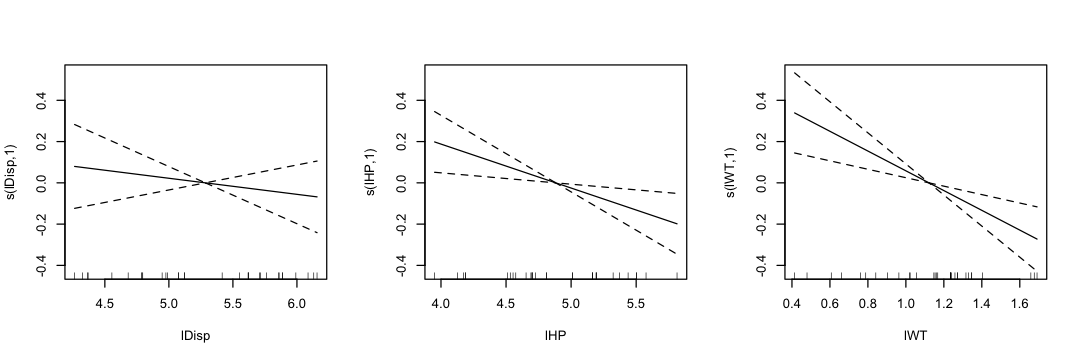

In [42]:
library(mgcv)

# Fit additive model
gam.model <- gam(lMPG ~ s(lDisp) + s(lHP) + s(lWT),
                data = mtcars1)

# Summary with estimated degrees of freedom
# summary(gam.model)

# Plot smooth terms
par(mfrow = c(1, 3))
plot(gam.model, se = TRUE)

## Binary Response: Logistic Regression

When the response is **binary** (success/failure, yes/no), ordinary linear regression is inappropriate because:
- Predictions can fall outside [0, 1]
- The linear model assumes constant variance, but binary data has variance that depends on the mean
- The distribution is binomial, not normal

**Logistic Regression Model**
$$
\pi_i = P(Y_i = 1 | X_i) = \frac{\exp(\eta_i)}{1 + \exp(\eta_i)}
$$

Where $\eta_i = \beta_0 + \beta_1 x_i^{(1)} + \cdots + \beta_m x_i^{(m)}$ is the **linear predictor**.

**Logit Link Function**
$$
\text{logit}(\pi_i) = \log\left(\frac{\pi_i}{1 - \pi_i}\right) = \eta_i
$$

**Interpretation of Coefficients**
- $\beta_j$ = change in **log-odds** per unit change in $x^{(j)}$
- $\exp(\beta_j)$ = **odds ratio** (multiplicative change in odds)
- If $\beta_j > 0$: Higher $x^{(j)}$ increases probability of success
- If $\beta_j < 0$: Higher $x^{(j)}$ decreases probability of success

## Generalized Linear Models (GLM)

**GLMs** unify various regression models under a single framework (Nelder & Wedderburn, 1972). They consist of three components:

1. **Random Component**: Response $Y_i$ follows a distribution from the **exponential family**
2. **Systematic Component**: Linear predictor $\eta_i = \sum_{j=0}^m \beta_j x_i^{(j)}$
3. **Link Function**: $g(\mu_i) = \eta_i$, where $\mu_i = E[Y_i]$

### Exponential Family

$$f(y_i; \mu_i, \phi) = \exp \left\langle \frac{y_i b(\mu_i) - c(\mu_i)}{\phi} w_i + d(y_i; \phi, w_i) \right\rangle$$

- The dispersion parameter $\phi$ is connected to the variance
- The value $w_i$ is a fixed known number (weighting)
- The function $d(y_i; \phi, w_i)$ scales the probability to 1.
- The functions $b(\mu_i)$ and $c(\mu_i)$ determine the distribution.

**Expected Value:**
$$\mu_i = \mathbb{E}[Y_i] = \frac{c'(\mu_i)}{b'(\mu_i)}$$

where $b'(\mu)$ and $c'(\mu)$ are the first derivatives with respect to $\mu$.

**Variance:**
$$\text{Var}(Y_i) = \frac{\phi}{w_i} V(\mu_i), \quad V(\mu_i) = \frac{1}{b'(\mu_i)}$$

 Distribution                       | Range of $Y$          | $\mathbb{E}[Y] = \mu$ | $\text{var}(Y)$          | Link $b(\mu)$             | $V(\mu)$                 | $\phi$ | $w$ |
 |------------------------------------|-----------------------|----------------------|--------------------------|---------------------------|--------------------------|--------|-----|
 | Gaussian $(\mu,\sigma^2)$          | $(-\infty, +\infty)$  | $\mu$ | $\sigma^2$               | $\mu$                     | $1$                      | $\sigma^2$ | $1$ |
 | prop; Binomial $(m,\pi)$    | $\frac{0,\dots,m}{m}$ | $\pi$ | $\frac{\pi(1-\pi)}{m}$ | $\log(\frac{\mu}{1-\mu})$         | $\mu(1-\mu)$             | $1$ | $m$ |
 | counts; Binomial $(m,\pi)$ | $\{0,\dots,m\}$       | $m\pi$ | $m\pi(1-\pi)$            | $\log(\frac{\mu}{m-\mu})$ | $\mu(1-\frac{\mu}{m})$ | $1$ | $1$ |
 | Poisson $(\lambda)$                | $\{0,1,\dots\}$       | $\lambda$ | $\lambda$                | $\log(\mu)$               | $\mu$                    | $1$ | $1$ |
 | Gamma $(\alpha,\beta)$             | $(0, \infty)$         | $\alpha/\beta$ | $\alpha/\beta^2$         | $-1/\mu$                  | $\mu^2$                  | $1/\alpha$ | $1$ |
 | Inverse Gauss.                     | $(0, \infty)$         | $\mu$ | $\mu^3/\lambda$          | $-1/\mu^2$                | $\mu^3$                  | $1/\lambda$ | $1$ |

- **Distribution:** The probability distribution of the response variable $Y$;Defines the random component of the GLM
- **Range of $Y$:** The support (set of possible values) for the response variable; Determines which distribution is appropriate for your data
- **$\mathbb{E}\langle Y\rangle = \mu$:** The expected value (mean) of the response; The target of your regression model
- **$\text{var}\langle Y\rangle$:** The variance of the response variable; Determines precision of estimates
- **$b\langle \mu\rangle$:** The canonical link function from the exponential family density; $\eta = b'(\mu)$
- **$V\langle \mu\rangle$:** The variance function; Connects mean to variance: $var(Y) = \frac{\phi}{w} V(\mu)$
- **$\phi$:** The dispersion parameter; Scales the variance: larger $\phi$ means more spread
- **$w$:** The prior weight for each observation; Known constant for each observation (e.g., $m$ for binomial)

:::{tip} Challenger Space Shuttle O-ring Failure

The 1986 Space Shuttle Challenger explosion was traced to O-ring failure. Engineers suspected that launch temperature affected failure probability. This is a classic application of logistic regression with a binary response (failure vs. no failure).

Data: Number of O-rings at risk (m), number failing (Fails), launch temperature (Temp in F), leak-check pressure (Pres in psi)

**GLM Formulation:**

$$
\begin{aligned}
\text{Fails} &\sim \text{Binomial}(m_i, \pi_i), \\
  & m_i \text{ is number of O-rings at risk}, \\
  & \pi_i \text{ is probability of failure}  \\
\mathbb{E}[Fails] &= m_i * \pi_i \\
\text{Link: } & \text{logit}(\pi_i) \\
\text{Linear Predictor: } & \beta_0 + \beta_1 \text{Pres} + \beta_2 \text{Temp}
\end{aligned}
$$
:::

In [43]:
# Fit logistic regression model
chal.glm <- glm(cbind(Fails, m-Fails) ~ Temp + Pres,
               family = binomial(link = logit),
               data = chal)
summary(chal.glm)

# Odds ratios
exp(coef(chal.glm))


Call:
glm(formula = cbind(Fails, m - Fails) ~ Temp + Pres, family = binomial(link = logit), 
    data = chal)

Coefficients:
             Estimate Std. Error z value Pr(>|z|)  
(Intercept)  3.409728   3.178539   1.073   0.2834  
Temp        -0.107747   0.044648  -2.413   0.0158 *
Pres         0.007380   0.006447   1.145   0.2523  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 24.230  on 22  degrees of freedom
Residual deviance: 16.565  on 20  degrees of freedom
AIC: 36.125

Number of Fisher Scoring iterations: 5


(Intercept)        Temp        Pres 
 30.2569995   0.8978546   1.0074069

- **Temperature coefficient**: -0.1077 (p = 0.0158)
  - Interpretation: Each 1F decrease in temperature multiplies the odds of failure by $\exp(0.1077) \approx 1.114$ (11.4% increase)
  - **Engineering implication**: At the launch temperature of 31F (well below previous launches), the failure probability was unacceptably high
- **Pressure coefficient**: 0.0074 (p = 0.2523)
  - Not statistically significant at 5% level

**Hypothesis Test:**

Does pressure affect failure probability?

$H_0: \beta_1 = 0$ (no effect), $H_1: \beta_1 \neq 0$ (effect exists)

Deviance test (more reliable than Wald for small samples):

In [44]:
# Compare models with and without Pres
chal.glm1 <- glm(cbind(Fails, m-Fails) ~ Pres + Temp,
                family = binomial, data = chal)
chal.glm2 <- glm(cbind(Fails, m-Fails) ~ Temp,
                family = binomial, data = chal)
anova(chal.glm1, chal.glm2, test = "Chisq")
# Result: p-value = 0.2174 > 0.05

,Resid. Df,Resid. Dev,Df,Deviance,Pr(>Chi)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,20,16.56510,NA,NA,NA
2,21,18.08633,-1,-1.521226,0.217434


**Conclusion**: Cannot reject $H_0$ → **No evidence that pressure affects failure probability**

**Confidence Interval for Temperature:**

In [45]:
confint(chal.glm1)
# Temp: [-0.201, -0.022]

Waiting for profiling to be done...



,2.5 %,97.5 %
(Intercept),-2.776236540,9.93358512
Pres,-0.004030283,0.02272544
Temp,-0.201164111,-0.02229717


- 95% CI for temperature coefficient: [-0.201, -0.022]
- Does not include 0 → confirms significant effect
- **Principle**: `confint()` uses deviance test statistic (more reliable than Wald)

**Prediction at 31F:**
The critical question: What was the predicted failure probability at the launch temperature of 31F?

In [46]:
# Predicted probability at 31°F (using average pressure)
new.data <- data.frame(Temp = 31, Pres = mean(chal$Pres))
pred.response <- predict(chal.glm2, newdata = new.data,
                         type = "response", se = TRUE)
# pred.response$fit: 0.8178 (81.78% probability of failure)

:::{warning}
Predicting on the **link scale** and transforming back guarantees confidence intervals stay within [0, 1], unlike direct prediction on the response scale. This is crucial for logistic regression.
:::

In [47]:
# WRONG METHOD (can exceed [0,1]): 95% confidence interval
pred.response$fit + c(-1, 1) * qnorm(0.975) * pred.response$se.fit
# [0.3465, 1.2891] - Invalid! Exceeds [0,1]

[1] 0.346496 1.289053

In [48]:
# CORRECT METHOD: 95% confidence interval
# Predict on link scale, then transform
pred.link <- predict(chal.glm2, newdata = new.data,
                     type = "link", se = TRUE)
ci.link <- pred.link$fit + c(-1, 1) * qnorm(0.975) * pred.link$se.fit
ci.response <- 1 / (1 + exp(-ci.link))  # [0.1596, 0.9907]

**Data Selection Lesson:**
Engineers considered using only data where O-rings showed thermal distress.
- **Problem**: This drops observations with no distress, which contain valuable information
- **Principle**: Never drop data based on the response variable - you never know if it influences the outcome
- **Solution**: Use all available data for analysis

## Inference for GLMs

### Deviances

**Deviance** measures the goodness of fit of a model:

- **Null deviance**: Measures total variation in the response (model with only intercept)
- **Residual deviance**: Measures variation not explained by the model
- **Difference in deviances**: Measures improvement from adding predictors

For nested models, the difference in residual deviances follows a $\chi^2$ distribution:
$$
\Delta D = D_{\text{reduced}} - D_{\text{full}} \sim \chi^2_{\text{df}}
$$

Where df = difference in number of parameters.

In [49]:
# Compare nested models
model.full <- glm(Calls ~ Center + Time, family = poisson, data = dial)
model.reduced <- glm(Calls ~ Center, family = poisson, data = dial)

# Deviance test
anova(model.full, model.reduced, test = "Chisq")

,Resid. Df,Resid. Dev,Df,Deviance,Pr(>Chi)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,7,5.737019,NA,NA,NA
2,8,6.316035,-1,-0.5790159,0.4466983


### Overdispersion

**Overdispersion** occurs when the observed variance exceeds what the model assumes:
- **Poisson**: Variance > mean
- **Binomial**: Variance > $n\pi(1-\pi)$

**Detection:**
$$
\hat{\phi} = \frac{\text{Residual Deviance}}{\text{Residual df}}
$$

If $\hat{\phi} > 1$, there is evidence of overdispersion.

**Example - Poisson GLM with Overdispersion**

The warpbreaks dataset contains the number of breaks in yarn during weaving, classified by wool type (A, B) and tension (L, M, H). This is a classic example where overdispersion is present.

**Model:**
$$
\text{breaks}_i \sim \text{Poisson}(\lambda_i)
\log(\lambda_i) = \beta_0 + \beta_1 \text{woolB}_i + \beta_2 \text{tensionM}_i + \beta_3 \text{tensionH}_i + \beta_4 \text{woolB}_i:\text{tensionM}_i + \beta_5 \text{woolB}_i:\text{tensionH}_i
$$

**R Output:**
```r
Coefficients:
            Estimate Std. Error z value Pr(>|z|)
(Intercept)  3.7967     0.0499  76.030  <2e-16 ***
woolB      -0.4566     0.0802  -5.694  1.24e-08 ***
tensionM   -0.6187     0.0844  -7.330  2.30e-13 ***
tensionH   -0.5958     0.0838  -7.112  1.15e-12 ***
woolB:tensionM 0.6382    0.1222   5.224  1.75e-07 ***
woolB:tensionH 0.1884    0.1299   1.450   0.147
```

**Interaction Term Significance:**
- **Null**: $\beta_4 = \beta_5 = 0$ (no interaction)
- **Alternative**: At least one interaction coefficient ≠ 0
- **Test**: Deviance test (drop1 with Chisq test)
- **R Code**:
```{code-block} r
# Test interaction term
drop1(WB.glm, test="Chisq")
# Result: p-value = 7.962e-07 < 0.05
```
- **Conclusion**: **Interaction term is needed** to explain the response

**Overdispersion Detection:**
- **Definition**: More dispersion in the data than the Poisson model allows (Poisson assumes mean = variance)
- **Detection**: Residual deviance / residual df = 182.31 / 48 = 3.798
- **Test**: `1 - pchisq(182.31, 48) = 0` (essentially 0) < 0.05
- **Conclusion**: **Strong evidence of overdispersion**

**Implications:**
- The Poisson model is **not adequate** to describe the data
- Statistical conclusions based on this model (including the interaction test) are **not valid**
- **Solution**: Use a quasi-Poisson model to account for overdispersion

**Modified Model:**

In [50]:
# Quasi-Poisson regression
WB.qPReg1 <- glm(breaks ~ wool*tension,
                 family = quasipoisson,
                 data = warpbreaks)
WB.qPReg1


Call:  glm(formula = breaks ~ wool * tension, family = quasipoisson, 
    data = warpbreaks)

Coefficients:
   (Intercept)           woolB        tensionM        tensionH  woolB:tensionM  
        3.7967         -0.4566         -0.6187         -0.5958          0.6382  
woolB:tensionH  
        0.1884  

Degrees of Freedom: 53 Total (i.e. Null);  48 Residual
Null Deviance:	    297.4 
Residual Deviance: 182.3 	AIC: NA

## Confidence Intervals for GLMs

**Wald-type Confidence Intervals:**
- Based on asymptotic normality of MLEs
- Simple to compute but can be inaccurate for small samples or sparse data
- May produce invalid ranges (e.g., probabilities outside [0,1])

**Deviance-based Confidence Intervals:**
- Based on likelihood ratio tests
- More reliable for small samples
- Guarantees intervals stay within valid range

In [51]:
# For GLMs, R uses Deviance-based methods by default with non-Gaussian families.
# For LMs, R uses confint.lm() that employs the t-distribution instead of the normal.
# For others, Wald is the default method

# Deviance-based (more reliable than Wald)
confint(model, method = "profile")

Waiting for profiling to be done...



,2.5 %,97.5 %
(Intercept),1.13549813,6.33152339
lDisp,-0.51927641,0.18451070
lHP,-0.42397279,0.10514015
lWT,-0.86856567,0.11258184
drat,-0.14255896,0.15090311
qsec,-0.05100941,0.07948022
wCarb,-0.37623548,0.07711063
wCyl,-0.23882915,0.61543063
wGear,-0.06812956,0.96759698
vs,-0.21424408,0.13380107


## Diagnostics and Model Adequacy Checking

**Model adequacy** is crucial - a model is only as good as its assumptions. Diagnostic plots help verify these assumptions.

### Essential Diagnostic Plots for GLMs

1. **Tukey-Anscombe Plot** (Residuals vs Fitted):
   - **Check**: Linear relationship, constant variance
   - **Problem**: Non-linear pattern → missing non-linear term
   - **Problem**: Funnel shape → heteroscedasticity

2. **Normal Q-Q Plot** (Quantiles of residuals vs theoretical):
   - **Check**: Normality of residuals
   - **Problem**: Points deviate from line → non-normal residuals
   - **Problem**: Heavy tails → outliers

3. **Scale-Location Plot** ($\sqrt{|\text{Residuals}|}$ vs Fitted):
   - **Check**: Constant variance
   - **Problem**: Non-constant spread → heteroscedasticity

4. **Residual vs Leverage**:
   - **Check**: Influential observations
   - **Problem**: Cook's distance > 1 → too influential
   - **Problem**: High leverage points → extrapolation

### Enhanced Diagnostics with Simulation

**Simulated envelopes** provide a more rigorous check by comparing observed diagnostic curves to what we'd expect under the model assumptions:

In [52]:
options(repr.plot.width = 9, repr.plot.height = 6)

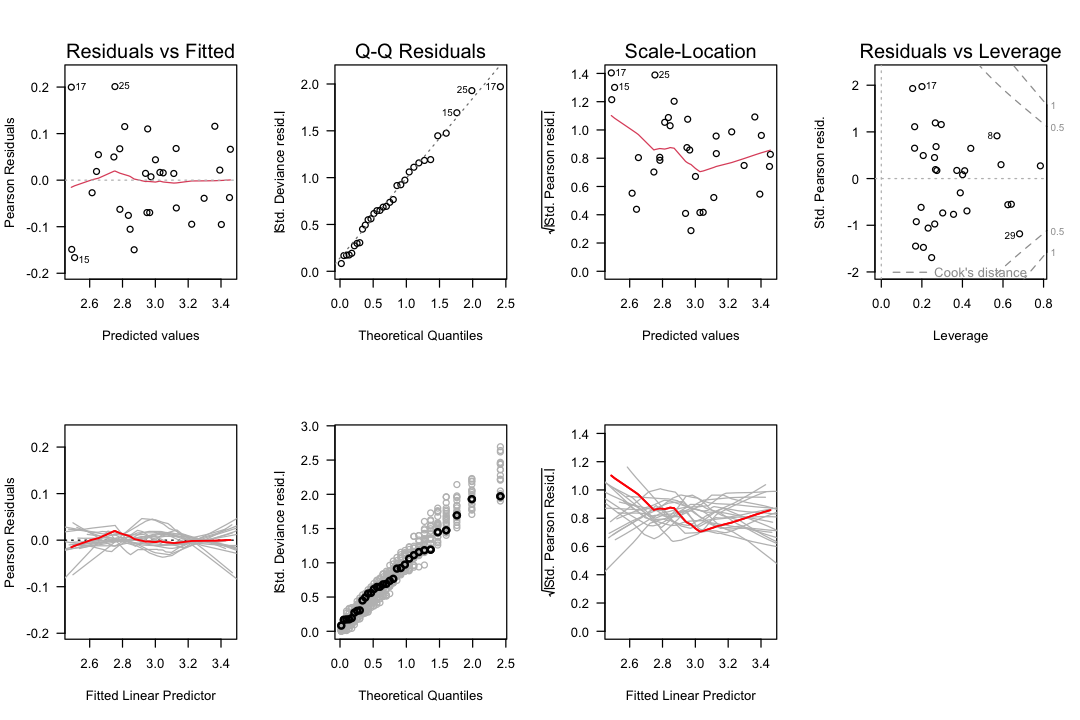

In [53]:
# Enhanced diagnostic plots with simulation (RFn_Plot-glmSim.R loaded in setup)
par(mfrow = c(2, 4), las = 1)
plot(model)
plot.glmSim(model, SEED = 4711)

**Interpretation:**
- If observed curves fall **within** the gray envelope (simulated fluctuation), there is **no evidence** against the assumption
- If observed curves fall **outside** the envelope, there is **evidence** the assumption is violated

**Example - Machine Failures Residual Analysis:**

A machinery runs in two modes. The question is whether the number of failures depends on operating time in each mode. After fitting a Poisson regression model, we perform a residual and sensitivity analysis.

**Diagnostic Plots Interpretation:**

1. **Tukey-Anscombe Plot**: Smoother indicates some non-constant expectation, but within stochastic fluctuation (gray spaghetti) → **Weak evidence against adequately specified expectation**
2. **Location-Scale Plot**: Smoother decreasing but within stochastic fluctuation → **No evidence against adequately specified variance**
3. **Normal Q-Q Plot**: Points scatter around line, all black points within gray points → **No evidence for outliers or distributional violations**
4. **Residual vs Leverage**: All Cook's distances < 1 → **No observation with too large influence**

**Overall Conclusion:** Model might be adequate, though there's a weak hint that expectation might not be constant (but limited data prevents strong conclusions).

**Statistical Soundness:** Because there is no serious evidence against model assumptions, the statistical conclusions from the hypothesis test and overdispersion check are **valid**.

**Example - Residual Analysis with Simulation:**

The six diagnostic plots (Tukey-Anscombe, Normal Q-Q, Scale-Location) with simulation envelopes (gray lines and points) provide additional insights.

**Purpose of Gray Lines and Points:**
- **Gray lines**: Show the scatter range of the smoother under model assumptions
- **Gray points**: Show the scatter range of data points under model assumptions
- **Interpretation**: If black (observed) structures lie **outside** the gray (simulated) structures, this is evidence the model does not adequately describe the data

**Residual and Sensitivity Analysis for Yarn Breaks:**

1. **Tukey-Anscombe Plot**:
   - **Observation**: Smoother is a reasonably straight horizontal line
   - **Comparison**: Within stochastic fluctuation (gray spaghetti)
   - **Conclusion**: **No evidence** that expectation is incorrectly specified

2. **Normal Q-Q Plot**:
   - **Observation**: Black points are **not** within stochastic fluctuation (gray points)
   - **Interpretation**: Evidence of **distortions of the distributional assumption**
   - **Art of violation**: Suggests **overdispersion**

3. **Scale-Location Plot**:
   - **Observation**: Red smoother has a weak trend, shifted upwards
   - **Comparison**: Outside stochastic fluctuation
   - **Conclusion**: **Evidence** that variance is incorrectly specified
   - **Art of violation**: Suggests **overdispersion**

**Overall Conclusion:** There is evidence that the model does not fit the data adequately. The identified violations suggest **overdispersion** is the main issue, which we addressed by using a quasi-Poisson model.

**Residual Types for GLMs:**
- **Response residuals**: $y_i - \hat{y}_i$ (observed - predicted)
- **Pearson residuals**: $(y_i - \hat{y}_i) / \sqrt{\text{Var}(\hat{y}_i)}$ (standardized)
- **Deviance residuals**: Contribute to deviance statistic

In [54]:
# Extract different residual types
residuals(model, type = "response")
residuals(model, type = "pearson")
residuals(model, type = "deviance")

1            2            3            4            5            6 
 0.016684552  0.043819993 -0.094694591  0.110108264  0.115123079 -0.069703008 
           7            8            9           10           11           12 
 0.018678630  0.068017137  0.014341396  0.014578932 -0.069674131  0.049804598 
          13           14           15           16           17           18 
 0.067408648 -0.062663332 -0.166369240 -0.148776853  0.199764297  0.115780521 
          19           20           21           22           23           24 
-0.037364849  0.066326610 -0.059735884 -0.105446569 -0.149515349 -0.027022280 
          25           26           27           28           29           30 
 0.201081666 -0.095255453 -0.038966585  0.021626565 -0.075692381  0.007258623 
          31           32 
 0.054828504  0.015648492

1            2            3            4            5            6 
 0.016684552  0.043819993 -0.094694591  0.110108264  0.115123079 -0.069703008 
           7            8            9           10           11           12 
 0.018678630  0.068017137  0.014341396  0.014578932 -0.069674131  0.049804598 
          13           14           15           16           17           18 
 0.067408648 -0.062663332 -0.166369240 -0.148776853  0.199764297  0.115780521 
          19           20           21           22           23           24 
-0.037364849  0.066326610 -0.059735884 -0.105446569 -0.149515349 -0.027022280 
          25           26           27           28           29           30 
 0.201081666 -0.095255453 -0.038966585  0.021626565 -0.075692381  0.007258623 
          31           32 
 0.054828504  0.015648492

1            2            3            4            5            6 
 0.016684552  0.043819993 -0.094694591  0.110108264  0.115123079 -0.069703008 
           7            8            9           10           11           12 
 0.018678630  0.068017137  0.014341396  0.014578932 -0.069674131  0.049804598 
          13           14           15           16           17           18 
 0.067408648 -0.062663332 -0.166369240 -0.148776853  0.199764297  0.115780521 
          19           20           21           22           23           24 
-0.037364849  0.066326610 -0.059735884 -0.105446569 -0.149515349 -0.027022280 
          25           26           27           28           29           30 
 0.201081666 -0.095255453 -0.038966585  0.021626565 -0.075692381  0.007258623 
          31           32 
 0.054828504  0.015648492

## Model Improvement: Finding Appropriate Transformations

**Generalized Additive Models (GAMs)** are excellent for exploring non-linear relationships in a data-driven manner:

## Extensions of GLMs

### Rate Models

**Rate models** analyze counts per unit **exposure** (e.g., accidents per kilometer driven, failures per machine-hour):

```{math}
E[Y_i] = \mu_i \cdot t_i
```

Where $t_i$ is the exposure (offset).

In [55]:
# Poisson regression with offset for ship damage data
glm(Damages ~ Year + Month + offset(log(Exposure)),
    family = poisson,
    data = ship)


Call:  glm(formula = Damages ~ Year + Month + offset(log(Exposure)), 
    family = poisson, data = ship)

Coefficients:
(Intercept)       Year65       Year70       Year75      Month75  
    -5.5607      -0.3086       0.2649     -18.2099           NA  

Degrees of Freedom: 19 Total (i.e. Null);  16 Residual
Null Deviance:	    13.64 
Residual Deviance: 10.54 	AIC: 26.54

**Interpretation:** The offset ensures we're modeling the **rate** (counts per unit exposure) rather than raw counts.

### Quasi-Likelihood Models

**Quasi-models** extend GLMs when the full distribution is not specified, requiring only the mean-variance relationship:

**Quasi-Poisson:**
```{math}
\text{Var}(Y_i) = \phi \cdot \mu_i
```

Where $\phi$ is the **dispersion parameter** estimated from data.

In [56]:
# Quasi-Poisson for overdispersed count data
qp.model <- glm(breaks ~ wool * tension,
                family = quasipoisson,
                data = warpbreaks)
summary(qp.model)

# Dispersion parameter
qp.model$dispersion  # Should be > 1 if overdispersed


Call:
glm(formula = breaks ~ wool * tension, family = quasipoisson, 
    data = warpbreaks)

Coefficients:
               Estimate Std. Error t value Pr(>|t|)    
(Intercept)     3.79674    0.09688  39.189  < 2e-16 ***
woolB          -0.45663    0.15558  -2.935 0.005105 ** 
tensionM       -0.61868    0.16374  -3.778 0.000436 ***
tensionH       -0.59580    0.16253  -3.666 0.000616 ***
woolB:tensionM  0.63818    0.23699   2.693 0.009727 ** 
woolB:tensionH  0.18836    0.25201   0.747 0.458436    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for quasipoisson family taken to be 3.76389)

    Null deviance: 297.37  on 53  degrees of freedom
Residual deviance: 182.31  on 48  degrees of freedom
AIC: NA

Number of Fisher Scoring iterations: 4


NULL

# Causality

## Best Practices and Key Takeaways

1. **Distinguish association from causation** - correlation does not imply causation. The shoe size and salary example demonstrates how a common cause (gender) can create spurious associations.
2. **Use DAGs** to represent causal assumptions explicitly. Nodes are variables, directed edges are potential causal effects. Use the `gRbase` and `gRain` packages to work with DAGs and Bayesian networks.
3. **Identify confounders** and adjust for them appropriately using the backdoor criterion. The Nutrition-Disease example shows how to find valid adjustment sets.
4. **Use d-separation** to determine conditional independencies in the graph. The sprinkler network example illustrates the three basic structures (chain, fork, collider) and their independence properties.
5. **Apply the backdoor criterion** to find valid adjustment sets for causal effect estimation. This allows estimating causal effects from observational data when appropriate variables are measured.
6. **Consider counterfactuals** for individual-level causal questions using Pearl's three-step method (abduction, action, prediction). The online sales example demonstrates practical counterfactual reasoning.
7. **Validate causal models** through sensitivity analysis, robustness checks, and external validation. Always question whether the causal assumptions are reasonable and test the stability of results.

## Why Causal Inference Matters

Traditional statistics and machine learning excel at finding **associations** and making **predictions**, but they cannot answer **causal questions** without additional assumptions. Causal inference is essential when we want to understand **what would happen if we changed something**.

**Key Distinction:**
- **Association**: $P(Y | X)$ - What is the probability of Y given X?
  Do people who drink more coffee tend to be more productive?
- **Intervention**: $P(Y | do(X = x))$ - What would Y be if we **set** X to x?
  If I drink 20 cups of coffee, will I be more productive?
- **Counterfactual**: $P(Y^{X=x} | X=x', Y=y')$ - What would Y have been if X had been x, given that X was actually x' and Y was y'?
  Would I have been more productive yesterday if I had drunk 20 cups of coffee instead of 2?

The first question can be answered with observational data, but the second and third require causal assumptions.

```{note}
Higher levels subsume lower levels: A model that can answer counterfactual questions can also answer intervention and association questions.
```

## Causal Graphical Models

**Causal graphical models** (DAGs - Directed Acyclic Graphs) provide a language for representing causal assumptions explicitly.

**Components:**
- **Nodes**: Random variables
- **Directed edges**: Potential causal effects
- **Absence of edge**: No direct causal effect

**Terminology:**
- **Parent**: Node with directed edge **to** another node
- **Child**: Node with directed edge **from** another node
- **Ancestor**: Node with directed path **to** another node
- **Descendant**: Node with directed path **from** another node
- **Adjacent**: Nodes connected by an edge

**Example - Bayesian Networks:**
Building and querying Bayesian networks using the `gRain` package:

In [61]:
library(gRain)

# Define CPTs with explicit levels
cptSeason <- cptable(~Season,
    values = c(0.5, 0.5),
    levels = c("winter", "summer"))

cptSprinkler <- cptable(~Sprinkler | Season,  # Use | not :
    values = matrix(c(0.5, 0.5, 0.9, 0.1), nrow = 2, byrow = TRUE),
    levels = list(Sprinkler = c("off", "on"),
                Season = c("winter", "summer")))

# Build network
bn <- compileCPT(list(Season = cptSeason, Sprinkler = cptSprinkler))
bn <- grain(bn)

# Query probabilities
# querygrain(bn, nodes = c("Season"), type = "marginal")
# querygrain(bn, nodes = c("Season", "Sprinkler"), type = "conditional")

**Graphical Building Blocks:**

1. **Chain (Mediation)**: $X \rightarrow Z \rightarrow Y$
   - X affects Y **through** Z
   - Example: Education → Income → Happiness

2. **Fork (Confounding)**: $X \leftarrow Z \rightarrow Y$
   - Z is a **common cause** of X and Y
   - Example: Gender → (Shoe Size, Salary)

3. **Collider (Selection)**: $X \rightarrow Z \leftarrow Y$
   - Z is a **common effect** of X and Y
   - Example: Rain → Wet ← Sprinkler

## Conditional Independence and D-Separation

### Conditional Independence
Two variables X and Y are **conditionally independent** given Z if:
$$
P(X, Y | Z) = P(X | Z) \cdot P(Y | Z)
$$

**D-Separation:** A path is **d-separated** (blocked) by a set of nodes Z if it contains a node that is:
- Not in Z, and
- Is a **collider** on that path

Two nodes X and Y are **d-separated** given Z if **all paths** between them are blocked by Z.

```{note}
D-separation in the graph implies conditional independence in **all** distributions compatible with the graph.
```

### D-Separation Rules

| Structure | Independence | Conditional Independence Given Z |
|-----------|--------------|------------------------------------|
| Chain: $X \rightarrow Z \rightarrow Y$ | Dependent | **Independent** (blocks chain) |
| Fork: $X \leftarrow Z \rightarrow Y$ | Dependent | **Independent** (blocks fork) |
| Collider: $X \rightarrow Z \leftarrow Y$ | Dependent | **Dependent** (opens collider) |

## DAG Analysis

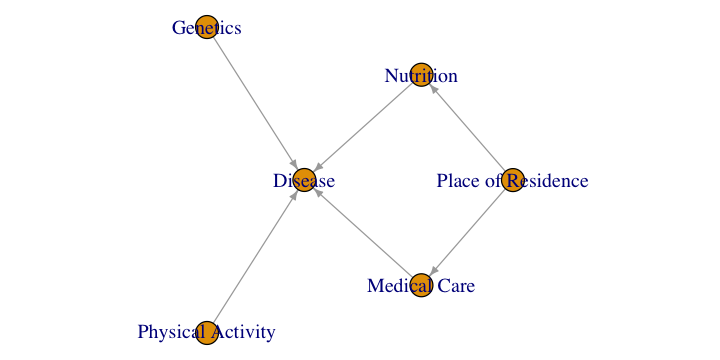

In [79]:
options(repr.plot.width = 6, repr.plot.height = 3)
library(gRbase)

set.seed(253)

g <- dag(
  c("Nutrition", "Place of Residence"),
  c("Disease", "Medical Care", "Genetics", "Physical Activity", "Nutrition"),
  c("Medical Care", "Place of Residence")
)
par(mar = c(0.1, 0.1, 0.1, 0.1))
plot(g)

### Descendants of Place of Residence
- _Answer:_ Medical Care, Nutrition, Disease
- _Explanation:_ Descendants are all nodes reachable via directed paths from Place of Residence. From Place of Residence, we can reach Nutrition directly, Medical Care directly, and Disease through Medical Care.

### Direct Causal Effect of Place of Residence on Disease
- _Answer:_ 0
- _Justification:_ There is no direct edge from Place of Residence to Disease in the DAG. The effect is only indirect through Medical Care.

### Independence Statements

i. Nutrition $\perp\!\!\!\perp$ Medical Care | Place of Residence ?
- _Correct:_ There is a **fork** at Place of Residence (common cause of both Nutrition and Medical Care)
- _Reason:_ Conditioning on the common cause (Place of Residence) blocks the path between Nutrition and Medical Care, making them conditionally independent

ii. Nutrition $\perp\!\!\!\perp$ Physical Activity | Disease ?
- _Incorrect:_ There is a **collider** at Disease (common effect of Nutrition and Physical Activity)
- _Reason:_ Conditioning on the collider (Disease) **opens** the path between Nutrition and Physical Activity, making them conditionally dependent

iii. Nutrition $\perp\!\!\!\perp$ Genetics | Medical Care ?
- _Correct:_ The collider is Disease (not in conditioning set)
- _Reason:_ Medical Care is not a descendant of Disease. The collider path (Nutrition $\rightarrow$ Disease $\leftarrow$ Genetics) remains blocked because Disease is not in the conditioning set and Medical Care is not its descendant.

### Regression for Total Causal Effect of Nutrition on Disease

To estimate the **total** causal effect of Nutrition on Disease, we must block the backdoor path: Nutrition $\leftarrow$ Place of Residence $\rightarrow$ Medical Care $\rightarrow$ Disease

```r
lm(Disease ~ Nutrition + PlaceOfResidence, data = data)
```

### Asymptotically Optimal Adjustment

The asymptotically optimal adjustment set minimizes the variance of the causal effect estimator:

$$
\text{pa}(\text{cn}(X, Y)) \text{without} \text{forb}(X, Y)
$$

- $\text{cn}(X, Y)$ = all causal nodes in the directed path from X to Y
- $\text{pa}(S)$ = parents of set S
- $\text{forb}(X, Y)$ = forbidden nodes (all descendants of causal nodes including X)

_Calculation:_
- $\text{cn}(Nutrition, Disease) = \{Disease\}$ (Disease is the only causal neighbor)
- $\text{pa}(\text{cn}(Nutrition, Disease)) = \{Nutrition, Genetics, Medical Care, Physical Activity\}$ (parents of Disease)
- $\text{forb}(Nutrition, Disease) = \{Nutrition, Disease\}$ (the variables themselves)

Optimal adjustment: $\{ Genetics, Medical Care, Physical Activity \}$

### D-Separation Testing
Testing conditional independence in DAGs and verifying with data:

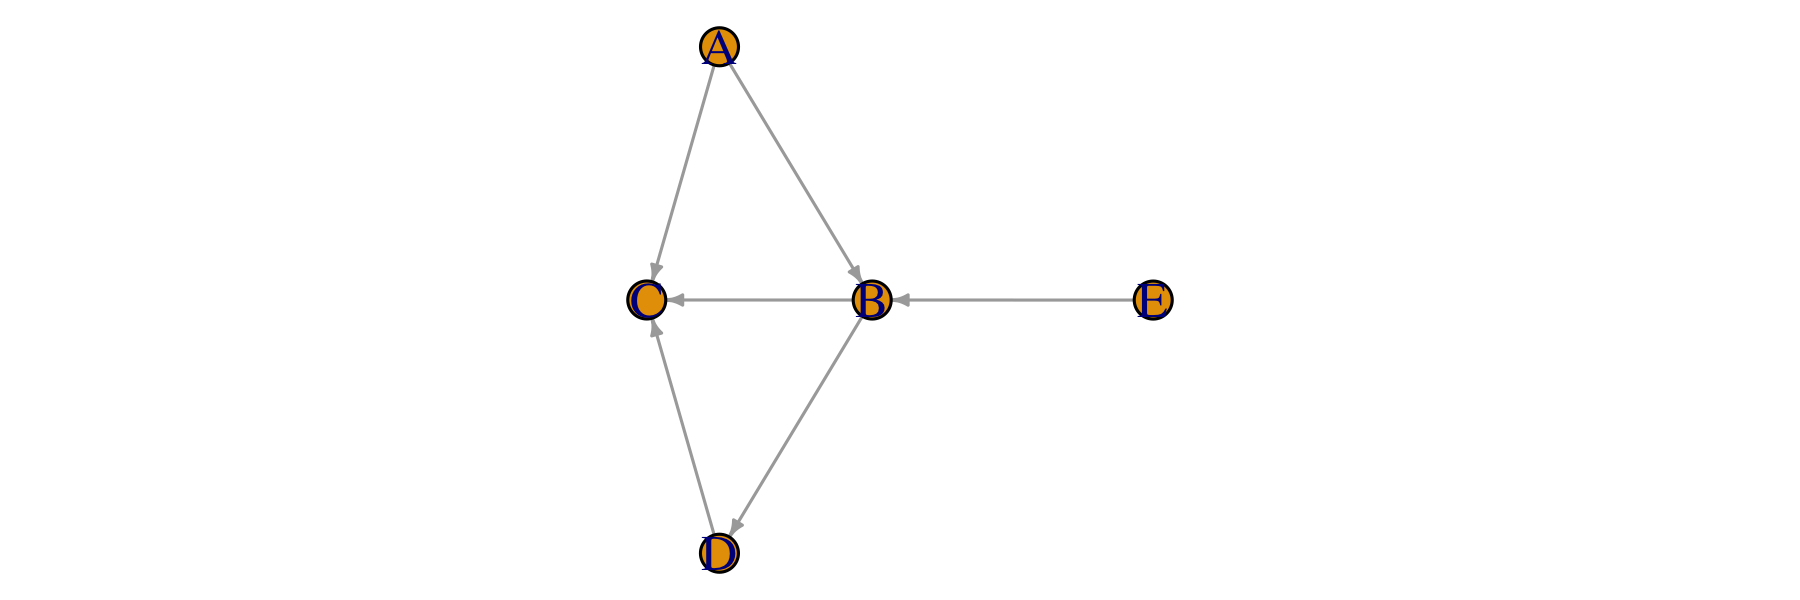

In [89]:
options(repr.plot.width = 6, repr.plot.height = 2)

library(gRbase)

d.separates <- function(a,b,c,dag){
    separates(a,b,c, moralize(ancestralGraph(union(union(a,b),c),dag)))
}

dag.model <- dag("A",c("B","A","E"),c("C","A","B","D"),c("D","B"),c("E"))

par(mar = c(0.1, 0.1, 0.1, 0.1))
plot(dag.model)

In [90]:
cat("Are E and D d-separated by Z = {B}?", d.separates("E", "D", c("B"), dag.model), "\n")
cat("Are E and C d-separated by Z = {A}?", d.separates("E", "C", c("A"), dag.model), "\n")
cat("Are A and D d-separated by Z = {B, C}?", d.separates("A", "D", c("B", "C"), dag.model), "\n")

Are E and D d-separated by Z = {B}? TRUE 
Are E and C d-separated by Z = {A}? FALSE 
Are A and D d-separated by Z = {B, C}? FALSE 


## Simpson's Paradox

**Simpson's Paradox** occurs when a trend appears in different groups of data but **disappears or reverses** when these groups are combined.

**Example: Layoffs**
- **Overall**: More layoffs in Department A than Department B
- **Within each gender**: More layoffs in Department B than Department A
- **Resolution**: Gender distribution differs between departments (more men in A, more women in B, and men are laid off more regardless of department)

**Causal Explanation:** The paradox arises because **gender** is a **confounder** - it affects both the department (exposure) and layoffs (outcome). When we aggregate across genders, the confounding effect creates the paradox.

**Solution:** Adjust for the confounder (gender) to see the true relationship within each gender group.


## Factorization of Joint Distributions

For a DAG, the joint distribution **factorizes** according to the graph structure:

$$
P(X_1, X_2, \ldots, X_n) = \prod_{i=1}^n P(X_i | \text{pa}(X_i))
$$

Where $\text{pa}(X_i)$ are the **parents** of node $X_i$ in the DAG.

**Example: Medical Diagnosis**
$$
P(D, S, C) = P(D) \cdot P(S | D) \cdot P(C | D)
$$

Where:
- D = Disease
- S = Symptom
- C = Test Result

**Interpretation:** Disease affects both Symptom and Test Result, but Symptom and Test Result are independent given Disease (d-separated by Disease).

## Causal Effect Estimation

**Causal effect** measures how an intervention on X affects Y:

$$
P(Y | do(X = x))
$$

**Adjustment Formula:**
If we can find a set Z that satisfies the **backdoor criterion**, we can estimate causal effects from observational data:

$$
P(Y | do(X = x)) = \sum_z P(Y | X = x, Z = z) \cdot P(Z = z)
$$

**Backdoor Criterion:**
A set of variables Z satisfies the backdoor criterion relative to X and Y if:
1. Z **blocks all backdoor paths** from X to Y
2. Z **does not contain any descendants** of X

**Finding Adjustment Sets:**
1. Identify all **backdoor paths** from X to Y
2. For each path, find a set that **blocks** it
3. Combine these sets, ensuring no new paths are opened

**Example - Adjustment Formula:**

Estimating causal effects with adjustment: Use backdoor criterion and adjust for all parents of Nutrition that are not descendants.

```{code-block} r
lm(Disease ~ Nutrition + PlaceOfResidence, data = data)
```

## Structural Causal Models (SCMs)

**Structural Causal Models** combine causal graphs with **structural equations** that describe the data-generating process:

$$
X_j = f_j(\text{pa}(X_j), E_j)
$$

Where:
- $X_j$ = endogenous variable
- $\text{pa}(X_j)$ = parents of $X_j$ in the causal graph
- $E_j$ = exogenous (noise) variable
- $f_j$ = structural function

**Linear SCMs:**

$$
X_j = \beta_{j0} + \sum_{i \in \text{pa}(X_j)} \beta_{ji} X_i + E_j
$$

**Direct vs. Total Causal Effects:**
- **Direct effect**: Effect of X on Y **not mediated** through other variables
- **Total effect**: Sum of direct effect + all indirect effects

**Example: Linear SCM**

$$
\begin{align*}
X &= E_X \\
Y &= \beta_{YX} X + E_Y \\
Z &= \beta_{ZX} X + \beta_{ZY} Y + E_Z
\end{align*}
$$

- **Direct effect of X on Y**: $\beta_{YX}$
- **Direct effect of X on Z**: $\beta_{ZX}$
- **Direct effect of Y on Z**: $\beta_{ZY}$
- **Total effect of X on Z**: $\beta_{ZX} + \beta_{ZY} \cdot \beta_{YX}$

**Estimating Causal Effects:**
For linear SCMs, causal effects can be estimated using regression with appropriate adjustment:

```{code-block} r
# Estimate total causal effect of Nutrition on Disease
# Adjust for confounding variables (Place of Residence)
lm(Disease ~ Nutrition + PlaceOfResidence, data = data)
```

**Assumptions of Linear SCMs:**
1. Known causal structure
2. Linear relationships
3. Uncorrelated errors
4. No unmeasured confounders

**Limitations:**
- Requires prior knowledge of causal structure
- Linear assumption may not hold
- Errors may be correlated in practice

**Example - Linear SCMs:**
Defining and working with linear structural causal models:

In [60]:
# Define SCM
X <- rnorm(100)
E_Y <- rnorm(100)
E_Z <- rnorm(100)
Y <- 2 + 1.5 * X + E_Y
Z <- 3 + 2 * X + 0.8 * Y + E_Z

# Estimate effects
lm(Y ~ X)
lm(Z ~ X + Y)


Call:
lm(formula = Y ~ X)

Coefficients:
(Intercept)            X  
      1.971        1.719  



Call:
lm(formula = Z ~ X + Y)

Coefficients:
(Intercept)            X            Y  
     3.0795       2.2095       0.8097  


## Interventional vs. Observational Data

**Experimental Data:**
- Researchers **randomly assign** treatments
- Groups are **comparable** (except for treatment)
- **Gold standard** for causal inference
- Example: Randomized controlled trial (RCT)

**Observational Data:**
- Researchers **observe** naturally occurring variation
- Groups may **differ systematically** (confounding)
- Requires **adjustment** for valid causal inference
- Example: Cohort study, case-control study

**Key Difference:**
- **Experimental**: $P(Y | X = x) = P(Y | do(X = x))$ (randomization blocks confounders)
- **Observational**: $P(Y | X = x) \neq P(Y | do(X = x))$ (confounding may be present)

**Example: Shoe Size and Salary**
- **Observational**: People with larger shoes tend to have higher salaries
- **Reason**: Gender affects both shoe size and salary (confounding)
- **Experimental**: If we randomly assign shoe sizes, no effect on salary
- **Conclusion**: No causal effect of shoe size on salary

**Example - Ice Cream, Temperature, Emergencies:**

**Context:** Observational data from 146 cities recording temperature (moderate/high), emergency calls (low/high), and ice cream sales (low/high).

**Causal Graph:**

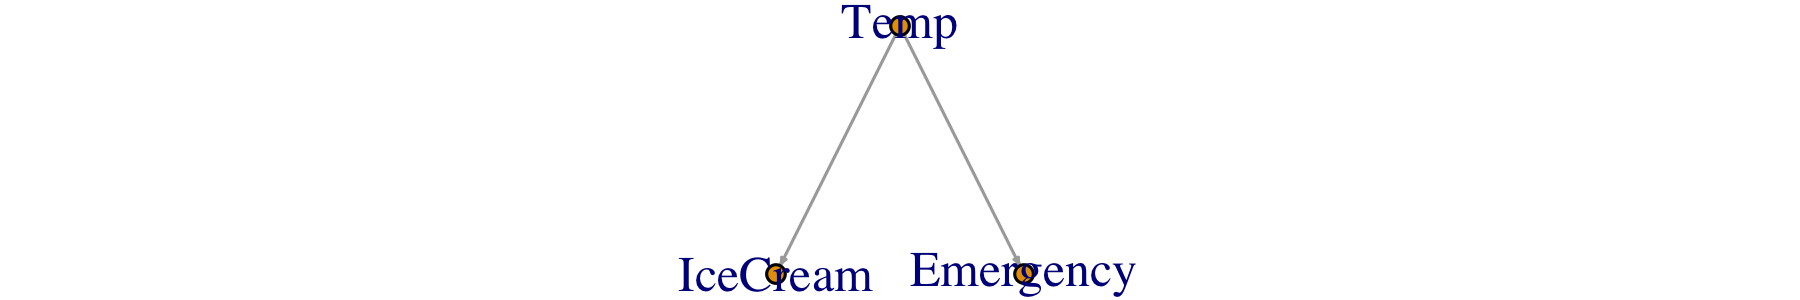

In [98]:
options(repr.plot.width = 6, repr.plot.height = 1)

library(gRbase)

dag.model <- dag(
    c("IceCream","Temp"),
    c("Emergency","Temp"))

par(mar = c(0.1, 0.1, 0.1, 0.1))
plot(dag.model)

**Why Classical Model Finds Relationship:**
- **Observation**: Ice cream sales and emergency calls are positively associated
- **Reason**: **Temperature** is a **confounding variable** - it affects both ice cream sales and emergency calls
- **Spurious correlation**: The association is due to the common cause, not a direct causal effect

**Conditional Probabilities:**
```{code-block} r
# P(nEmergencies = high | IceCream = high)
(14 + 2) / 103  # 0.1553

# P(nEmergencies = high | IceCream = low)
(4 + 1) / 43   # 0.1163

# Risk ratio
0.1553 / 0.1163  # 1.34 times higher
```

**Interventional Probabilities:**

**do(IceCream = high) meaning:** An intervention that sets ice cream sales to high for everyone, **regardless** of temperature or other factors.

**Difference between P(Y|X) and P(Y|do(X)):**
- **P(Y|X)**: Conditional probability - likelihood of Y among those who **happened to have** X
- **P(Y|do(X))**: Interventional probability - likelihood of Y **if we set** X to a specific value
- In most cases: **P(Y|X) ≠ P(Y|do(X))** due to confounding

**How the Graph Changes with do(IceCream = high):**
- The arrow from Temperature → IceCream is **removed** (intervention makes IceCream independent of Temperature)
- Temperature still affects Emergency Calls directly

**Calculating P(nEmergency = high | do(IceCream = high)):**
Using the adjustment formula:
$$
P(Y|do(X)) = \sum_z P(Y|X,Z=z) \cdot P(Z=z)
$$

```{code-block} r
# P(Temp = high) = 88/146 = 0.6027
# P(Temp = moderate) = 58/146 = 0.3973

# P(nEmergency = high | IceCream = high, Temp = high)
14 / (56 + 14)  # 0.2000

# P(nEmergency = high | IceCream = high, Temp = moderate)
2 / (31 + 2)    # 0.0606

# Interventional probability
0.2000 * 0.6027 + 0.0606 * 0.3973  # 0.1446
```

**Calculating P(nEmergency = high | do(IceCream = low)):**
```{code-block} r
# P(nEmergency = high | IceCream = low, Temp = high)
4 / (14 + 4)  # 0.2000

# P(nEmergency = high | IceCream = low, Temp = moderate)
1 / (24 + 1)  # 0.0400

# Interventional probability
0.2000 * 0.6027 + 0.0400 * 0.3973  # 0.1498
```

**Causal Effect of IceCream on Emergency:**
$$
ACE = P(nEmergency = high | do(IceCream = high)) - P(nEmergency = high | do(IceCream = low))
$$

```{code-block} r
0.1446 - 0.1498  # -0.0052
```

**Conclusion:** The estimated causal effect is **approximately 0**, suggesting **no causal effect** of ice cream sales on emergency calls. The observed association (1.34 times higher risk) is entirely due to **confounding by temperature**. This demonstrates why it's crucial to distinguish between association and causation.


## Instrumental Variables (IV)

When **confounders are unmeasured**, standard regression cannot estimate causal effects. **Instrumental variables** provide a solution.

**Valid Instrument Z must satisfy:**
1. **Relevance**: Z is associated with X (not too weak)
2. **Exclusion restriction**: Z has no direct effect on Y (only through X)
3. **Independence**: Z is independent of all confounders of X and Y

**Two-Stage Least Squares (2SLS):**
1. Regress X on Z to get predicted values $\hat{X}$
2. Regress Y on $\hat{X}$ to estimate causal effect

```{code-block} r
library(AER)

# 2SLS using ivreg
iv.model <- ivreg(Y ~ X + W | Z + W, data = data)
summary(iv.model)
```

**Example: Education and Earnings**
- **X**: Education (years)
- **Y**: Earnings
- **Z**: Quarter of birth (affects education due to school entry age, but not earnings directly)
- **Assumption**: Quarter of birth is independent of ability, family background, etc.

## Counterfactual Reasoning

**Counterfactuals** answer questions like: "What would have happened if...?" for specific individuals.

**Pearl's Three-Step Method:**

1. **Abduction**: Use observed data to infer the distribution of exogenous variables
   - Estimate the structural error terms from observed data

2. **Action**: Modify the structural equations to reflect the intervention
   - Set the variable of interest to its counterfactual value

3. **Prediction**: Use the modified model to predict the counterfactual outcome
   - Compute the new value based on the modified equations

**Example - Online Sales Counterfactual:**

Given observed: Visits = 179, Discount = 19%, Sales = 101
Question: What would sales be if Discount = 10%?

**Estimated SCM from LiNGAM:**
Using the LiNGAM algorithm on historical sales data:

```{code-block} r
library(pcalg)
fit.sales <- lingam(dat_sales)
B <- round(fit.sales$Bpruned, 2)
colnames(B) <- rownames(B) <- colnames(dat_sales)
B
#        sales adv visits discount
# sales     0 0.00   0.24    0.18
# adv       0 0.00   0.00    0.00
# visits    0 1.79   0.00    0.00
# discount  0 0.00   0.00    0.00
```

**Estimated DAG:**
- **Adv → Visits** (coefficient: 1.79)
- **Visits → Sales** (coefficient: 0.24)
- **Discount → Sales** (coefficient: 0.18)
- No direct effect of Adv on Sales (only indirect through Visits)

**Step 1 - Abduction:**
```{code-block} r
# Estimate structural error for Sales
ES <- 101 - (55.65 + 0.24 * 179 + 0.18 * 19)
# ES = -1.03
```

**Step 2 - Action:**
Modify SCM for intervention do(Discount = 10):
$$
\begin{align*}
Adv &\leftarrow 27.71 + E_A \\
Visits &\leftarrow 165.28 + 1.79 \cdot Adv + E_V \\
Discount &\leftarrow 10  \text{(Intervention)} \\
Sales &\leftarrow 55.65 + 0.24 \cdot Visits + 0.18 \cdot Discount + E_S
\end{align*}
$$

**Step 3 - Prediction:**
```{code-block} r
visits <- 179  # Held constant (no intervention on visits)
discount <- 10  # Intervention
Sales <- 55.65 + 0.24 * visits + 0.18 * discount + ES
# Sales = 99.38
```

**Conclusion:** If the discount had been 10% instead of 19%, they would have sold approximately **99 items** (2 fewer than the observed 101).

**Example - Pearl's Three-Step Method:**
General template for counterfactual reasoning:

```{code-block} r
# Pearl's three-step method
# Step 1: Abduction
ES <- observed.Y - (beta0 + beta1 * observed.X)

# Step 2: Action
# Modify structural equation for intervention

# Step 3: Prediction
counterfactual.Y <- beta0 + beta1 * intervention.X + ES
```

## Markov Equivalence

**Markov Equivalence** refers to the fact that different DAGs can represent the **same conditional independence relationships**.

**Markov Equivalent Classes:**
- **Chains and forks** are Markov equivalent
- **CPDAGs** (Completed Partially Directed Acyclic Graphs) represent equivalence classes

**Example:**
The following DAGs are Markov equivalent (they encode the same conditional independencies):
- $X \rightarrow Y \rightarrow Z$
- $X \leftarrow Y \rightarrow Z$
- $X \leftarrow Y \leftarrow Z$

All three imply: $X \perp\!\!\!\perp Z | Y$

**Implications:**
- Without additional assumptions, we cannot distinguish between Markov equivalent DAGs from observational data alone
- We need **experimental data** or **strong assumptions** to identify the true causal structure


## Causal Structure Learning

**Causal structure learning** is the process of discovering causal relationships from data.

### PC Algorithm (Peter & Clark, 1991)

The **PC algorithm** is a constraint-based method that:
1. Starts with a **fully connected undirected graph**
2. Tests for **conditional independencies** in the data
3. **Removes edges** where conditional independence is found
4. **Orients edges** based on v-structures (colliders)

```{code-block} r
library(pcalg)

# Create skeleton (undirected graph)
skeleton <- pc(data, alpha = 0.05)

# Orient edges
pc.fit <- pc(skeleton, data, alpha = 0.05)

# Visualize
plot(pc.fit)
```

**Assumptions:**
- **Causal sufficiency**: All common causes are measured
- **Causal Markov condition**: D-separation implies conditional independence
- **Faithfulness**: No independence relationships are "accidental"

### LiNGAM Algorithm (Linear Non-Gaussian Acyclic Model)

**LiNGAM** identifies the **full causal structure** (not just Markov equivalence class) by assuming:
- **Linear relationships**
- **Non-Gaussian errors**
- **Acyclic structure**

**How it works:** Uses **Independent Component Analysis (ICA)** to identify the causal order.

```{code-block} r
library(pcalg)

# Fit LiNGAM model
fit.lingam <- lingam(data)

# B matrix contains edge weights
B <- fit.lingam$Bpruned
colnames(B) <- rownames(B) <- colnames(data)

# Confidence intervals
ci <- fit.lingam$ci

# Visualize
plot(fit.lingam)
```

**Example: Online Sales Data**
```{code-block} r
# Fit LiNGAM to sales data
fit.sales <- lingam(dat_sales)
B <- round(fit.sales$Bpruned, 2)

# Resulting DAG:
# Adv -> Visits -> Sales
# Discount -> Sales
# (No direct effect of Adv on Sales, only through Visits)
```

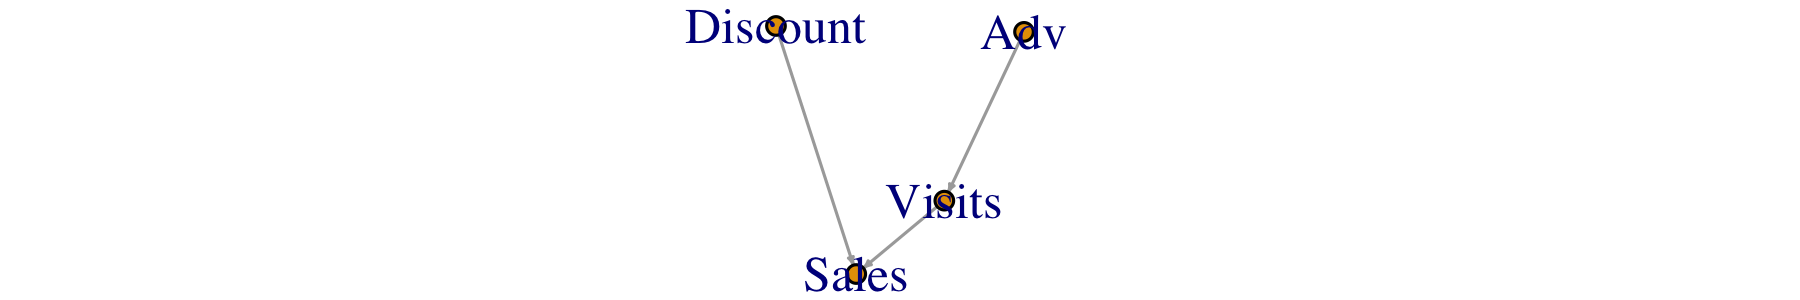

In [97]:
options(repr.plot.width = 6, repr.plot.height = 1)

library(gRbase)

dag.model <- dag(
    c("Sales","Visits", "Discount"),
    c("Visits","Adv"))

par(mar = c(0.1, 0.1, 0.1, 0.1))
plot(dag.model)

## Four Steps of Causal Inference

**Step 1: Create a Causal Model**
- Use **expert knowledge** to specify a DAG
- Represent all relevant variables and their causal relationships

**Step 2: Identify the Causal Effect**
- Determine if the causal effect can be **identified** from observational data
- Use **d-separation** and **backdoor criterion** to find valid adjustment sets

**Step 3: Estimate the Causal Effect**
- Apply **adjustment formula** or other identification strategies
- Use appropriate statistical methods (regression, matching, etc.)

**Step 4: Test/Validate the Results**
- Check **sensitivity** to modeling assumptions
- Test **robustness** to different specifications
- Validate with **external data** if available